In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
dataset_path = "/content/drive/MyDrive/data/seg_train"

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Аймен Аманжол', 'Colab Notebooks', 'Презентация без названия.gslides', 'АйменНурай.pdf', 'IMG_0399.pdf', 'Анализ презентация.gslides', 'seg_pred', 'seg_test.zip', 'seg_train.zip']


In [17]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/seg_train.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [18]:
with zipfile.ZipFile("/content/drive/MyDrive/seg_test.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [19]:
import os

print(os.listdir("/content/data"))

['seg_train', 'seg_test']


In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [21]:
train_path = "/content/data/seg_train"
test_path  = "/content/data/seg_test"

In [22]:
img_size = (150, 150)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [23]:
normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

In [25]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(150,150,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 399s 1s/step - accuracy: 0.6151 - loss: 0.9798 - val_accuracy: 0.7495 - val_loss: 0.6867
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.7591 - loss: 0.6466 - val_accuracy: 0.7904 - val_loss: 0.5888
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.8311 - loss: 0.4672 - val_accuracy: 0.8033 - val_loss: 0.5711
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 435s 1s/step - accuracy: 0.8805 - loss: 0.3294 - val_accuracy: 0.7990 - val_loss: 0.6280
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 423s 1s/step - accuracy: 0.9277 - loss: 0.2097 - val_accuracy: 0.7837 - val_loss: 0.7778


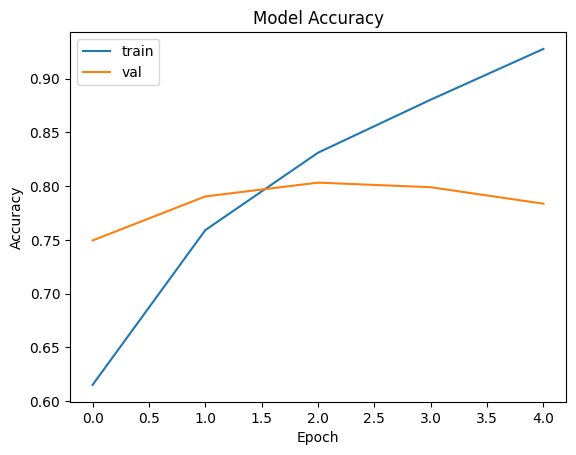

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

In [29]:
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([y for x, y in val_ds], axis=0)

y_pred = np.argmax(model.predict(val_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 316ms/step
              precision    recall  f1-score   support

   buildings       0.15      0.14      0.15       439
      forest       0.17      0.16      0.17       473
     glacier       0.18      0.17      0.17       463
    mountain       0.17      0.14      0.16       500
         sea       0.18      0.25      0.21       456
      street       0.15      0.13      0.14       475

    accuracy                           0.17      2806
   macro avg       0.17      0.17      0.17      2806
weighted avg       0.17      0.17      0.17      2806



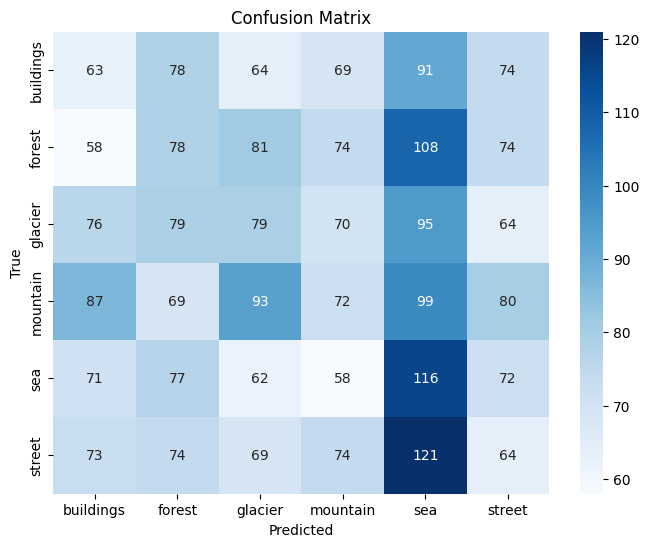

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()